<a href="https://colab.research.google.com/github/Lamiya-56/Full-RFM-Segmentation-and-Customer-Profiling/blob/main/Full_RFM_Segmentation_and_Customer_Profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [309]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [310]:
df=pd.read_csv("/content/sales_data_sample (1).csv", encoding='latin1')
df.head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
5,10168,36,96.66,1,3479.76,10/28/2003 0:00,Shipped,4,10,2003,...,9408 Furth Circle,NaN,Burlingame,CA,94217,USA,NaN,Hirano,Juri,Medium
6,10180,29,86.13,9,2497.77,11/11/2003 0:00,Shipped,4,11,2003,...,"184, chausse de Tournai",NaN,Lille,NaN,59000,France,EMEA,Rance,Martine,Small
7,10188,48,100.00,1,5512.32,11/18/2003 0:00,Shipped,4,11,2003,...,"Drammen 121, PR 744 Sentrum",NaN,Bergen,NaN,N 5804,Norway,EMEA,Oeztan,Veysel,Medium
8,10201,22,98.57,2,2168.54,12/1/2003 0:00,Shipped,4,12,2003,...,5557 North Pendale Street,NaN,San Francisco,CA,NaN,USA,NaN,Murphy,Julie,Small
9,10211,41,100.00,14,4708.44,1/15/2004 0:00,Shipped,1,1,2004,...,"25, rue Lauriston",NaN,Paris,NaN,75016,France,EMEA,Perrier,Dominique,Medium


In [311]:
df.shape

(2823, 25)

In [312]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [313]:
df.isnull().sum()

,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0
YEAR_ID,0


In [314]:
df.duplicated().sum()

np.int64(0)

In [315]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

In [316]:
last_date = df['ORDERDATE'].max()
print(f"Datadakı ən son tarix: {last_date}")
reference_date = last_date + pd.Timedelta(days=1)

Datadakı ən son tarix: 2005-05-31 00:00:00


In [317]:
reference_date

Timestamp('2005-06-01 00:00:00')

In [318]:
rfm = df.groupby('CUSTOMERNAME').agg({
    'ORDERDATE': lambda x: (reference_date - x.max()).days, # Recency - Müştəri sonuncu dəfə neçə gün əvvəl alış-veriş edib?
    'ORDERNUMBER': 'nunique',                             # Frequency - Müştərinin neçə dənə unikal sifariş nömrəsi olduğunu sayır.
    'SALES': 'sum'                                        # Monetary - Müştərinin etdiyi bütün alış-verişlərin qiymətini toplayır.
})

In [319]:
rfm

,ORDERDATE,ORDERNUMBER,SALES
CUSTOMERNAME,,,
"AV Stores, Co.",196,3,157807.81
Alpha Cognac,65,3,70488.44
Amica Models & Co.,265,2,94117.26
"Anna's Decorations, Ltd",84,4,153996.13
Atelier graphique,188,3,24179.96
...,...,...,...
"Vida Sport, Ltd",275,2,117713.56
Vitachrome Inc.,208,3,88041.26
"Volvo Model Replicas, Co",194,4,75754.88


In [320]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [321]:
rfm

,Recency,Frequency,Monetary
CUSTOMERNAME,,,
"AV Stores, Co.",196,3,157807.81
Alpha Cognac,65,3,70488.44
Amica Models & Co.,265,2,94117.26
"Anna's Decorations, Ltd",84,4,153996.13
Atelier graphique,188,3,24179.96
...,...,...,...
"Vida Sport, Ltd",275,2,117713.56
Vitachrome Inc.,208,3,88041.26
"Volvo Model Replicas, Co",194,4,75754.88


In [322]:
# Scoring (1–4 arası ballandırma)
# Recency: Kiçik rəqəm (yaxın tarix) daha yaxşıdır -> 4 bal
rfm["R"] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])  # pd.qcut funksiyası datanı bərabər şəkildə qruplara ayırır.
# Frequency və Monetary: Böyük rəqəm daha yaxşıdır -> 4 bal
rfm["F"] = pd.qcut(rfm['Frequency'].rank(method="first"), 4, labels=[1, 2, 3, 4])
#pd.qcut eyni rəqəmləri fərqli qruplara bölə bilmir və xəta verir. .rank(method="first") hər müştəriyə unikal bir sıra nömrəsi verərək bu problemi həll edir.
rfm["M"] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]) #Ən çox pul xərcləyən ilk 25%-lik dilimə 4 bal, ən az xərcləyən sonuncu 25%-ə 1 bal verilir.

In [323]:
# RFM_Segment (string formatında birləşdirmə)
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

#Burada balları yan-yana düzürük. Məsələn, R=4, F=4, M=4 olan müştəri üçün kod "444" olur.
#"444" dərhal bizə deyir ki, bu müştəri hər üç kateqoriya üzrə ən yaxşıdır.

In [324]:
rfm

,Recency,Frequency,Monetary,R,F,M,RFM_Segment
CUSTOMERNAME,,,,,,,
"AV Stores, Co.",196,3,157807.81,2,2,4,224
Alpha Cognac,65,3,70488.44,4,2,2,422
Amica Models & Co.,265,2,94117.26,1,1,3,113
"Anna's Decorations, Ltd",84,4,153996.13,3,4,4,344
Atelier graphique,188,3,24179.96,2,2,1,221
...,...,...,...,...,...,...,...
"Vida Sport, Ltd",275,2,117713.56,1,2,3,123
Vitachrome Inc.,208,3,88041.26,2,4,3,243
"Volvo Model Replicas, Co",194,4,75754.88,2,4,2,242


In [325]:
# Seqmentlərin adlandırılması (Rule-based)
def segment_mapping(df):
    r, f, m = int(df['R']), int(df['F']), int(df['M'])

    if r == 4 and f == 4 and m == 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r >= 3 and f <= 2:
        return 'Needs Attention'
    else:
        return 'Lost'

rfm['Segment_Name'] = rfm.apply(segment_mapping, axis=1)

**Champions:**
if r == 4 and f == 4 and m == 4:

Həm son alış-verişi çox yenidir (4), həm çox tez-tez gəlir (4), həm də çox pul xərcləyir (4). Bunlar ən mükəmməl müştərilərindir.

**Loyal (Sadiq Müştərilər):**
elif r >= 3 and f >= 3:

Son vaxtlar alış-veriş ediblər (3 və ya 4) və tez-tez gəlirlər (3 və ya 4). Champion olmasalar da, biznesini ayaqda tutan əsas kütlədir.

**At Risk (Riskdə olanlar):**
elif r <= 2 and f >= 3:

Onlar əvvəllər çox tez-tez gəlirdilər (f >= 3), amma son vaxtlar (çoxdandır) mağazaya uğramırlar (r <= 2).

Bu müştərilər bizi tərk etmək üzrədir, onları geri qazanmaq üçün nəsə etmək lazımdır.

**Needs Attention (Diqqət tələb edənlər):**
elif r >= 3 and f <= 2:

Son vaxtlar gəliblər (r >= 3), amma hələ cəmi 1-2 dəfə alış-veriş ediblər (f <= 2).

Bunlar yeni müştərilər ola bilər. Onları "Loyal" etmək üçün diqqət göstərməliyik.

**Lost (İtirilmişlər):**
else:

Yuxarıdakı kateqoriyaların heç birinə girməyənlər. Adətən həm çoxdandır gəlmirlər, həm də az alış-veriş ediblər.

In [326]:
rfm

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,Segment_Name
CUSTOMERNAME,,,,,,,,
"AV Stores, Co.",196,3,157807.81,2,2,4,224,Lost
Alpha Cognac,65,3,70488.44,4,2,2,422,Needs Attention
Amica Models & Co.,265,2,94117.26,1,1,3,113,Lost
"Anna's Decorations, Ltd",84,4,153996.13,3,4,4,344,Loyal
Atelier graphique,188,3,24179.96,2,2,1,221,Lost
...,...,...,...,...,...,...,...,...
"Vida Sport, Ltd",275,2,117713.56,1,2,3,123,Lost
Vitachrome Inc.,208,3,88041.26,2,4,3,243,At Risk
"Volvo Model Replicas, Co",194,4,75754.88,2,4,2,242,At Risk


In [327]:
# Summary Table (Xülasə Hesabatı)
summary = rfm.groupby('Segment_Name').agg({
    'Recency': ['count', 'mean'],
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()
summary.columns = ['Segment Name', 'Customer Count', 'Avg Recency', 'Avg Frequency', 'Avg Monetary']

print("Müştəri Seqmentləri Xülasəsi")
summary

Müştəri Seqmentləri Xülasəsi


,Segment Name,Customer Count,Avg Recency,Avg Frequency,Avg Monetary
0,At Risk,11,224.181818,3.363636,108864.877273
1,Champions,9,19.444444,8.111111,290097.736667
2,Lost,35,300.685714,2.171429,73828.208857
3,Loyal,26,101.769231,3.423077,111308.429615
4,Needs Attention,11,91.727273,2.909091,67839.008182


Champions ən dəyərli qrupdur: Bu seqment həm ən yüksək alış tezliyinə (8.1), həm də ən yüksək orta xərcə (290,097) malikdir. Onlar həm də ən son alış-veriş edənlərdir (orta hesabla 19 gün əvvəl).


---


"Lost" müştərilərin sayı narahatlıq doğurur: 35 nəfərlə ən böyük qrupdur və orta hesabla 300 gündür alış-veriş etmirlər. Bu, müştəri itkisinin yüksək olduğunu göstərir.


---


"Loyal" müştərilərin potensialı: 26 nəfərlik bu qrup kifayət qədər aktivdir, lakin onların orta xərcləri (111,308) "Champion"lardan xeyli aşağıdır. Onları daha baha məhsullara yönləndirmək olar.


---


"At Risk" və "Needs Attention" qrupları kritikdir: Bu qruplardakı 22 müştəri (11+11) itirilmək üzrədir. Xüsusilə "At Risk" qrupunun pul dəyəri (108,864) yüksək olduğu üçün onları geri qazanmaq üçün təcili kampaniyalara ehtiyac var.

# VİZUALLAŞDIRMA

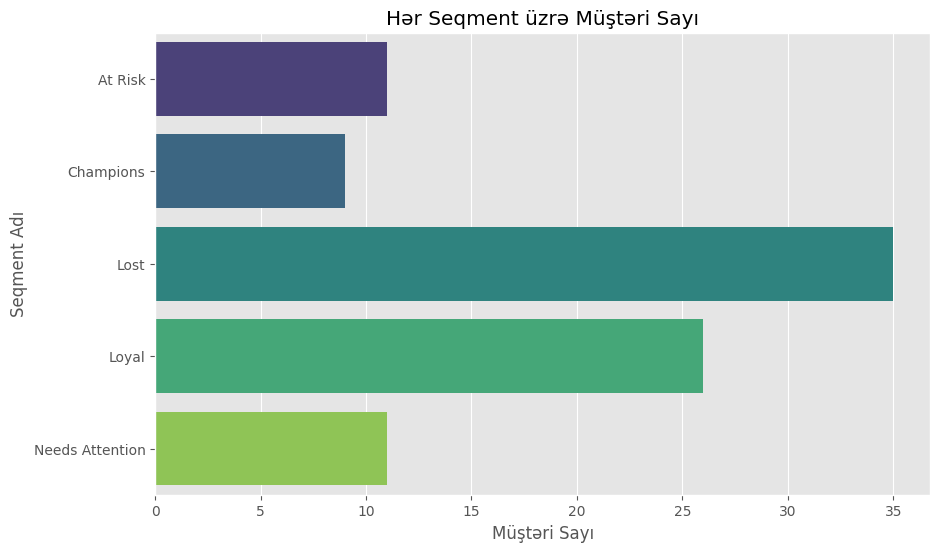

In [328]:
plt.figure(figsize=(10, 6))
# summary_table-dən istifadə edirik (əvvəlki kodda yaratdığımız)
sns.barplot(x='Customer Count', y='Segment Name', data=summary, palette='viridis', hue='Segment Name', legend=False)
plt.title('Hər Seqment üzrə Müştəri Sayı')
plt.xlabel('Müştəri Sayı')
plt.ylabel('Seqment Adı')
plt.show()

Ən böyük kütlə "Lost" seqmentindədir: Müştərilərin çox hissəsinin (35 nəfər) artıq itirilmiş olması biznes üçün ciddi siqnaldır. Bu, müştəri saxlama strategiyasının zəif olduğunu göstərir.

"Loyal" seqmentinin 26 nəfərlə ikinci böyük qrup olması müsbət haldır. Bu kütlə biznesin dayanıqlığını təmin edən əsas sütundur.

"At Risk" və "Needs Attention" təhlükəsi: Bu iki seqment birlikdə 22 müştəri təşkil edir. Əgər onlara qarşı xüsusi təkliflər və ya geri qazanma kampaniyaları tətbiq edilməsə, bunlar da tezliklə "Lost" kateqoriyasına keçə bilər.

"Champions" azlıqdadır: Ən dəyərli müştəri qrupunun (9 nəfər) sayca ən kiçik olması normaldır, lakin hədəf "Loyal" müştəriləri bu qrupa keçirmək olmalıdır.

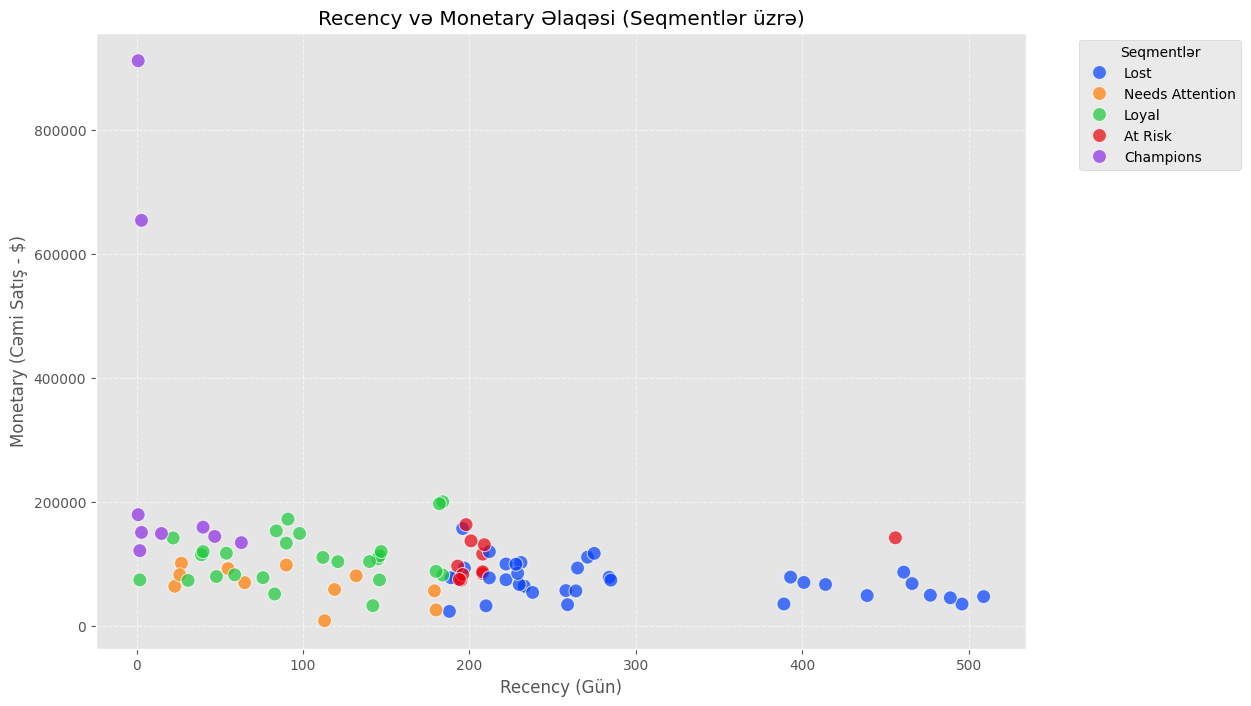

In [329]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Recency', y='Monetary', hue='Segment_Name', data=rfm, s=100, palette='bright', alpha=0.7)
plt.title('Recency və Monetary Əlaqəsi (Seqmentlər üzrə)')
plt.xlabel('Recency (Gün)')
plt.ylabel('Monetary (Cəmi Satış - $)')
plt.legend(title='Seqmentlər', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Champions" Seqmentinin Dominantlığı

Qrafikin sol yuxarı küncündəki bənövşəyi nöqtələr (Champions) - onlar həm ən aşağı Recency (yəni çox yaxın zamanda alış-veriş ediblər), həm də ən yüksək Monetary dəyərə malikdirlər. Xüsusilə iki nöqtə 600,000 və 900,000 dollar həddini keçərək digər bütün müştərilərdən kəskin fərqlənir (outliers).

"Lost" və "At Risk" Klasterləri

Qrafikin sağ tərəfinə doğru getdikcə (Recency artdıqca) göy (Lost) və qırmızı (At Risk) nöqtələrin sıxlaşdığını görürük.

Bu müştərilərin böyük hissəsi 200 gündən çoxdur ki, geri qayıtmır.

Onların Monetary dəyəri aşağıdır (əsasən 200,000-dən aşağı), bu da göstərir ki, itirilən kütlənin əksəriyyəti kiçik məbləğli alış-veriş edənlərdir.

"Loyal" Müştərilərin Stabilliyi

Yaşıl nöqtələr (Loyal) 0-200 gün aralığında paylanıb. Onlar bəlkə Champions qədər çox pul xərcləmirlər, lakin mütəmadi olaraq orta məbləğlərdə (təxminən 100,000 - 200,000 arası) alış-veriş edərək biznesin stabil gəlirini formalaşdırırlar.

"At Risk" içindəki İstisna

Diqqət yetirsək, sağ tərəfdə (təxminən 450-ci gündə) tək bir qırmızı nöqtə (At Risk) var ki, onun Monetary dəyəri digər "itirilmiş" müştərilərdən yüksəkdir. Bu müştəri çoxdan gəlməsə də, vaxtilə böyük alış-veriş edib. Onu geri qazanmaq üçün xüsusi cəhd göstərməyə dəyər.

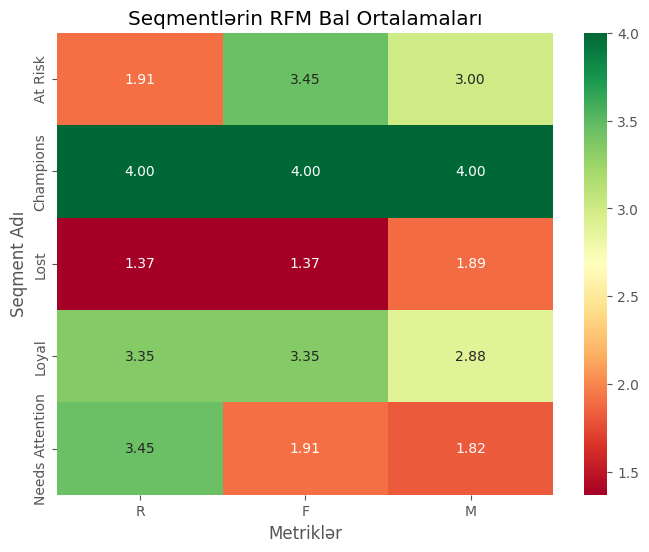

In [330]:
# Balların ortalamasını hesablayırıq
rfm_scores = rfm.copy()
rfm_scores[['R', 'F', 'M']] = rfm_scores[['R', 'F', 'M']].astype(int)
heatmap_data = rfm_scores.groupby('Segment_Name')[['R', 'F', 'M']].mean()

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt=".2f", cbar=True)
plt.title('Seqmentlərin RFM Bal Ortalamaları')
plt.ylabel('Seqment Adı')
plt.xlabel('Metriklər')
plt.show()

"Champions" qrupu hər üç metrik üzrə (R, F, M) maksimum balla (4.00) tam yaşıl zonadadır; bu bizim ideal müştəri profilimizdir.


---


"Lost" seqmenti həm yenilik (R), həm də tezlik (F) baxımından ən aşağı ballardadır (1.37); bu kütlə artıq platformadan tamamilə soyuyub.


---


 "Needs Attention" qrupunun yenilik balı (R=3.45) yaxşı olsa da, tezlik (F=1.91) və pul dəyəri (M=1.82) çox aşağıdır; deməli, yeni gələn və ya təkrar qayıdan bu müştəriləri aktivləşdirməkdə çətinlik çəkirik.


---


"At Risk" seqmenti keçmişdə tez-tez alış-veriş etsə də (F=3.45), hal-hazırda gəlmirlər (R=1.91); Bu müştəriləri geri qazanmaqla itirilmiş gəliri sürətlə bərpa edə bilərik.

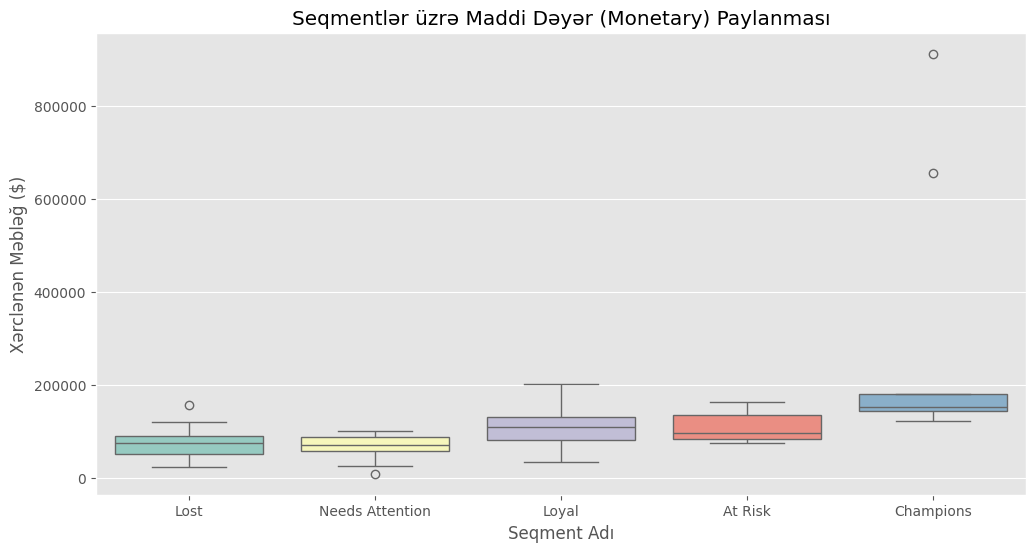

In [331]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Segment_Name', y='Monetary', data=rfm, palette='Set3',hue='Segment_Name', legend=False)
plt.title('Seqmentlər üzrə Maddi Dəyər (Monetary) Paylanması')
plt.xlabel('Seqment Adı')
plt.ylabel('Xərclənən Məbləğ ($)')
plt.show()

* **Champions seqmenti:** Bu qrupda iki müştəri ümumi paylanmadan kəskin fərqlənərək ($600,000$ və $900,000$+) biznesin ən böyük gəlir mənbəyinə çevrilib.


---


* **Loyal və At Risk oxşarlığı:** Maraqlıdır ki, "At Risk" qrupunun orta xərcləmə səviyyəsi "Loyal" müştərilərlə demək olar ki, eynidir. Bu da o deməkdir ki, biz faktiki olaraq sadiq müştərilərimizlə eyni dəyərdə olan kütləni itirmək üzrəyik.


---


* **Aşağı dəyişkənlik:** "Needs Attention" və "Lost" seqmentlərində xərcləmələr həm daha azdır, həm də nöqtələr bir-birinə çox yaxındır (qutular dardır). Bu müştərilər əsasən kiçik və standart alış-verişlər edənlərdir.



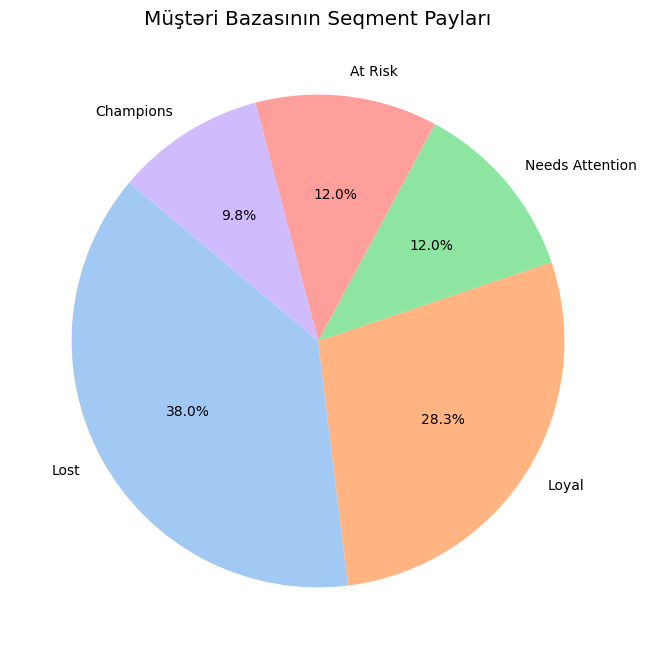

In [332]:
plt.figure(figsize=(8, 8))
segment_counts = rfm['Segment_Name'].value_counts()
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Müştəri Bazasının Seqment Payları')
plt.show()

Müştəri bazamızın 38%-i artıq "Lost" (İtirilmiş) statusundadır. Bu, bizdə hər 10 müştəridən təxminən 4-nün aktivliyini tamamilə itirdiyini göstərir

"Loyal" seqmenti 28.3% ilə bazamızın ikinci ən böyük hissəsidir; bu qrupun sadiqliyini qorumaq biznesin davamlılığı üçün şərtdir

"At Risk" və "Needs Attention" qruplarının hər biri 12% paya malikdir. Bu, bazanın dörddə birinin (24%) tərəddüd etdiyini və hər iki tərəfə (sadiqliyə və ya itkiyə) meyil edə biləcəyini göstərir.

"Champions" seqmentinin 9.8% olması, gəlirimizin böyük hissəsini təmin edən bu kiçik qrupun nə qədər dəyərli olduğunu təsdiqləyir

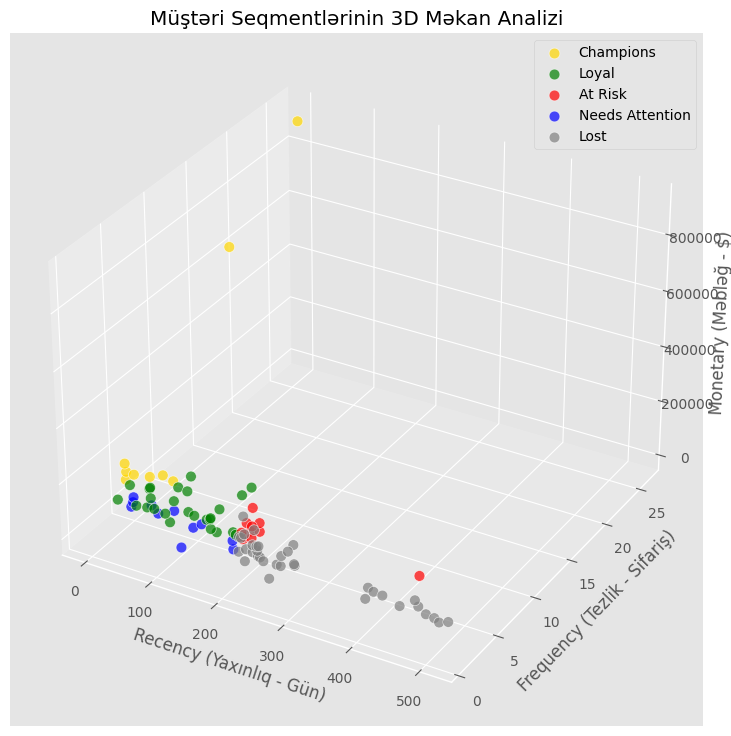

In [333]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Seqmentlərə rəng təyin edirik
colors = {'Champions': 'gold', 'Loyal': 'green', 'At Risk': 'red', 'Needs Attention': 'blue', 'Lost': 'grey'}

for segment, color in colors.items():
    subset = rfm[rfm['Segment_Name'] == segment]
    ax.scatter(subset['Recency'], subset['Frequency'], subset['Monetary'],
               c=color, label=segment, s=60, alpha=0.7, edgecolors='w')

ax.set_xlabel('Recency (Yaxınlıq - Gün)')
ax.set_ylabel('Frequency (Tezlik - Sifariş)')
ax.set_zlabel('Monetary (Məbləğ - $)')
ax.set_title('Müştəri Seqmentlərinin 3D Məkan Analizi')
ax.legend()
plt.show()

"Champions" (qızılı nöqtələr) qrafikin yuxarı hissəsində həm tezlik, həm də gəlir baxımından digərlərindən tamamilə ayrılır. Onlar biznesin ən üst təbəqəsini təşkil edir.

Müştərilərimizin böyük hissəsi qrafikin aşağı müstəvisində (aşağı Monetary və Frequency) toplanıb. Bu, bazamızın əsasən kiçik və seyrək alış-veriş edənlərdən ibarət olduğunu göstərir.

"Lost" (boz) və bəzi "At Risk" (qırmızı) nöqtələrin sağ tərəfə (Recency oxu üzrə uzağa) doğru uzanması, onların artıq sistemdən nə dərəcədə uzaqlaşdıqlarını sübut edir.

Yaşıl nöqtələr (Loyal) Champions ilə aşağı seqmentlər arasında bir keçid zonası yaradır. Bizim strateji məqsədimiz bu nöqtələri "yuxarı" (Frequency və Monetary oxları üzrə) qaldırmaqdır.

In [334]:
import plotly.express as px

fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Segment_Name',
    # Müştəri adlarını görmək üçün indeksi (CUSTOMERNAME) əlavə edirik
    hover_name=rfm.index,
    # Əlavə olaraq balları da görmək olar
    hover_data={'R': True, 'F': True, 'M': True, 'Segment_Name': False},
    title='Müştəri Seqmentlərinin Detallı 3D Analizi',
    opacity=0.8,
    width=1000,
    height=700
)

fig.update_layout(
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.8),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()